In [19]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Lab Assignment 3**

## Assignment Metadata

Write down your information here including author name, your ASU ID, and the file creation date.

### You must use this provided framework as-is and follow all the directions stated in there:
*	Do NOT edit or otherwise change any part of this framework except the cells you have been instructed to code.
*	You must NOT import any additional python packages to complete this assignment

### Note that, points will be deducted for notebooks that:
*	do not follow the saving guidelines/naming convention
*	do not compile/run
*	do not follow all the instructions in the framework
*	are incomplete
*	have logical errors
*	don’t result in the expected output



## Exercise 1 (Gradient Descent)

* In this assignment, you will first use the gradient descent algorithm to find the optimal value of w1 which minimizes the given lost function (Steps 1.1 through 1.5). You will earn 5% points for each step and 25% in total.

* You will run the algorithm for 4 different scenarios, each with a different value of alpha. For each scenario, you will log the responses in the last cell of this notebook (Step 1.6). You will earn 5% points for each scenario and 20%  in total.

In [ ]:
# DO NOT edit this cell!
# You must use this lost function and its derivative as-is

# lost at particular value of w1
def calc_J(w1):
    return (5.5*w1*w1 - 1463*w1 + 100812.5)

# slope at particular value of w1
def calc_dJ_dw1(w1):
    return (11*w1 - 1463)

In [ ]:
# First, complete coding Steps 1.1 through 1.5 in this cell.
# Then, run this cell for each of the four scenarios below,
# and log your responses for each scenario run in the next cell (Step 1.6)
alpha=0.08; niterations = 25; w1 = 60 # Scenario 1
# alpha=0.05; niterations = 25; w1 = 60 # Scenario 2
# alpha=0.15; niterations = 25; w1 = 60 # Scenario 3
# alpha=0.19; niterations = 25; w1 = 60 # Scenario 4

# Step 1.1: calculate current value of J at current value of w1
J = calc_J(w1)

# Step 1.2: print w1 (rounded to 2 decimal places) and J (rounded to 2 decimal places)
print(f"w1: {round(w1, 2)}, J: {round(J, 2)}")

# run gradient descent for niterations
for i in range(niterations):

    # Step 1.3: calculate new value of w1
    w1 = w1 - alpha * calc_dJ_dw1(w1)

    # Step 1.4: calculate new value of J at new w1
    J = calc_J(w1)

    # Step 1.5: print w1 (rounded to 2 decimal places) and J (rounded to 2 decimal places)
    print(f"w1: {round(w1, 2)}, J: {round(J, 2)}")


w1: 60, J: 32832.5
w1: 124.24, J: 3945.06
w1: 131.95, J: 3529.08
w1: 132.87, J: 3523.09
w1: 132.98, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0
w1: 133.0, J: 3523.0


In [ ]:
# Step 1.6: for each Scenario, answer the following questions based on the output (20%)
# type your answers below for each question
#
### Scenario 1 (alpha=0.08; niterations = 25; w1 = 60):
# did the cost steadily decrease as training progressed? Yes
# did the gradient descent algorithm converge? Yes
# what is the minimum lost? 3523.0
# what is the optimal value of w1? 133.0
# in how many iterations did gradient descent converge (at which row # in the output)? Row 5
#
### Scenario 2 (alpha=0.05; niterations = 25; w1 = 60):
# did the cost steadily decrease as training progressed? Yes
# did the gradient descent algorithm converge? Yes
# what is the minimum lost? 3523.0
# what is the optimal value of w1? 133.0
# in how many iterations did gradient descent converge (at which row # in the output)? Row 13
#
### Scenario 3 (alpha=0.15; niterations = 25; w1 = 60):
# did the cost steadily decrease as training progressed? No — cost oscillated above and below the minimum before converging
# did the gradient descent algorithm converge? Yes
# what is the minimum lost? 3523.0
# what is the optimal value of w1? 133.0
# in how many iterations did gradient descent converge (at which row # in the output)? Row 23
#
### Scenario 4 (alpha=0.19; niterations = 25; w1 = 60):
# did the cost steadily decrease as training progressed? No — cost exploded, increasing to over 2 million by iteration 25
# did the gradient descent algorithm converge? No — algorithm diverged
# what is the minimum lost? N/A — diverged
# what is the optimal value of w1? N/A — diverged
# in how many iterations did gradient descent converge (at which row # in the output)? N/A — did not converge

## Exercise 2 (Single Neuron)

### Then, you will apply deep learning thinking in modeling a single neuron to build logistic regression and linear regression models. You need also to Apply the idea of vectorization to efficiently train your models and implement gradient descent from scratch (using multiple iterations of the forward pass, backward propagation, and gradient descent steps) to minimize the loss functions and determine model parameters.

### Specifically, there are two parts in this assignment:
* In the first part, you will train a logistic regression model using the breast cancer data set. This part has 7 parts (2.1.1 through 2.1.7) that you will need to code (see framework for more details).
* In the second part, you will train a linear regression model using the diabetes data set. This part has 7 parts (2.2.1 through 2.2.7) that you will need to code (see framework for more details).

In [ ]:
### DO NOT EDIT THIS CELL!!!
### DO NOT IMPORT ANY ADDITIONAL PACKAGES

import numpy as np
import scipy
from sklearn import metrics
import matplotlib.pyplot as plt
%matplotlib inline

### PART 1

* Logistic Regression for Binary Classification using the breast cancer dataset

* We aren't going to preprocess data or split into train/test since the focus here is purely on the gradient descent algorithm

* NOTE: YOU WILL ONLY EDIT ONE CELL FOR PART-1 (SEE BELOW) (5% for each step, but 25% in total)

In [ ]:
### DO NOT EDIT THIS CELL!!!

# read the breast cancer dataset from sklearn
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()

# feature matrix X: mxn
X = dataset.data
print ("X: ", X.shape)

# target vector y: mx1
y = dataset.target
y = y.reshape(y.shape[0], 1)
print ("y: ", y.shape)

# number of samples: m
m = X.shape[0]
print ("m: ", m)

# number of features: n
n = X.shape[1]
features = dataset.feature_names
print ("n: ",n)
print ("features: ", features)

X:  (569, 30)
y:  (569, 1)
m:  569
n:  30
features:  ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


0.92


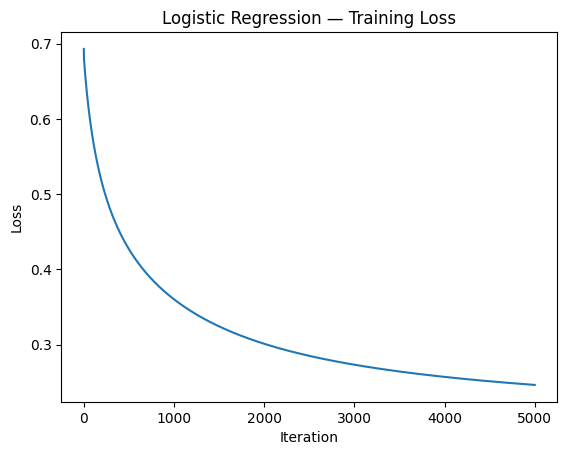

In [ ]:
### THIS IS THE ONLY CELL YOU MUST EDIT FOR PART-1

# train the logistic regression model

# initialize hyperparameters nepochs and alpha
nepochs = 5000
alpha = 2.5e-6

# initialize model parameters w and b
w = np.zeros((n,1))
b = 0

# this list will collect loss for each iteration
costs = []

### (2.1.1) repeat for nepochs
for i in range(nepochs):

    ### (2.1.2) forward pass (calculate current loss)
    Z = np.dot(X, w) + b
    A = scipy.special.expit(Z)
    J = metrics.log_loss(y, A)

    ### (2.1.3) backward propagation (calculate current gradient)
    dZ = A - y
    dW = (1/m) * np.dot(X.T, dZ)
    db = (1/m) * np.sum(dZ)

    ### (2.1.4) gradient descent (update parameters)
    w = w - alpha * dW
    b = b - alpha * db

    ### (2.1.5) append loss to costs
    costs.append(J)

### (2.1.6) accuracy on training data
Z = np.dot(X, w) + b
A = scipy.special.expit(Z)
yhat = np.round(A)
print(round(metrics.accuracy_score(y, yhat), 2))

### (2.1.7) plot costs
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title("Logistic Regression — Training Loss")
plt.show()

In [ ]:
### DO NOT EDIT THIS CELL!!!

# compare results from your implementation to that of SGDClassifier
# your accuracy score above should match (or be very close to) what you get from here

nepochs = 5000
alpha = 2.5e-6
y = y.reshape(y.shape[0],) # to avoid warning

from sklearn.linear_model import SGDClassifier
clf = SGDClassifier(loss='log_loss', # loss function for logistic regression
                    penalty=None, alpha=0, # no regularization
                    max_iter=nepochs, tol=None, # stop based only on nepochs
                    shuffle=False, random_state=0, # don't shuffle, use random state to replicate results
                    learning_rate='constant', eta0=alpha) # constant learning rate of alpha
clf.fit(X,y)
print (round(clf.score(X,y),2))

0.92


### Part 2

* Linear Regression using the diabetes dataset

* We aren't going to preprocess data or split  into train/test since the focus here is purely on the gradient descent algorithm

* NOTE: YOU WILL ONLY EDIT ONE CELL FOR PART-2 (SEE BELOW) (5% for each step, but 25% in total)

In [ ]:
### DO NOT EDIT THIS CELL!!!

# read the diabetes dataset from sklearn
from sklearn.datasets import load_diabetes

dataset = load_diabetes()

# feature matrix X: mxn
X = dataset.data
print ("X: ", X.shape)

# target vector y: mx1
y = dataset.target
y = y.reshape(y.shape[0], 1)
print ("y: ", y.shape)

# number of samples: m
m = X.shape[0]
print ("m: ", m)

# number of features: n
n = X.shape[1]
features = dataset.feature_names
print ("n: ",n)
print ("features: ", features)

X:  (442, 10)
y:  (442, 1)
m:  442
n:  10
features:  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


2880.49
0.51


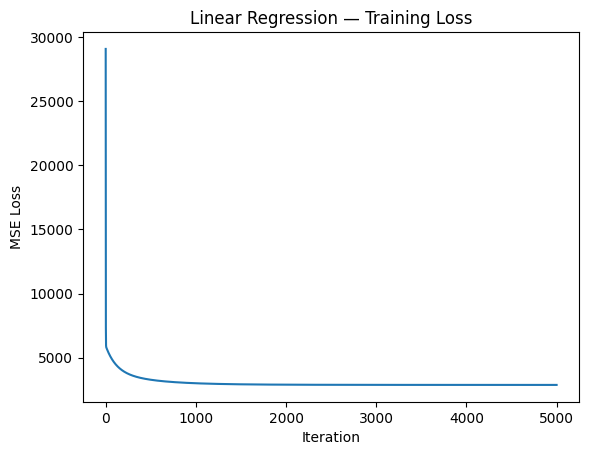

In [ ]:
### THIS IS THE ONLY CELL YOU MUST EDIT FOR PART-2

# train the linear regression model

# initialize hyperparameters nepochs and alpha
nepochs = 5000
alpha = 0.5

# initialize model parameters w and b
w = np.zeros((n,1))
b = 0

# this list will collect loss for each iteration
costs = []

### (2.2.1) repeat for nepochs
for i in range(nepochs):

    ### (2.2.2) forward pass (calculate current loss)
    Z = np.dot(X, w) + b
    J = metrics.mean_squared_error(y, Z)

    ### (2.2.3) backward propagation (calculate current gradient)
    dZ = Z - y
    dW = (1/m) * np.dot(X.T, dZ)
    db = (1/m) * np.sum(dZ)

    ### (2.2.4) gradient descent (update parameters)
    w = w - alpha * dW
    b = b - alpha * db

    ### (2.2.5) append loss to costs
    costs.append(J)

### (2.2.6) MSE and R2 on training data
Z = np.dot(X, w) + b
print(round(metrics.mean_squared_error(y, Z), 2))
print(round(metrics.r2_score(y, Z), 2))

### (2.2.7) plot costs
plt.plot(costs)
plt.xlabel("Iteration")
plt.ylabel("MSE Loss")
plt.title("Linear Regression — Training Loss")
plt.show()

In [ ]:
### DO NOT EDIT THIS CELL!!!

# compare results from our implementation to that of SGDRegressor
# your mse and r2 score above should match (or be very close to) what you get from here

nepochs = 5000
alpha = 0.5
y = y.reshape(y.shape[0],) # to avoid warning

from sklearn.linear_model import SGDRegressor
clf = SGDRegressor(loss='squared_error', # mse for linear regression
                    penalty=None, alpha=0, # no regularization
                    max_iter=nepochs, tol=None, # stop based on only on nepochs
                    shuffle=False, random_state=0, # don't shuffle, use random state to replicate results
                    learning_rate='constant', eta0=alpha) # constant learning rate of alpha
clf.fit(X,y)
yhat = clf.predict(X)
print (round(metrics.mean_squared_error(y, yhat),2))
print (round(clf.score(X,y),2))

2922.89
0.51


## Acknowledgment

Acknowledge here if you have used any GenAI tools in this assignment and anyone you have worked together with on this assignment. (5%)

I am 100% AI augmented and I directed & orchestrated the AI to assist in my learning.

In [20]:
!pip install jupyter
!pip install nbconvert
!jupyter nbconvert "/content/drive/MyDrive/Colab Notebooks/LA3_Cook_Matthew.ipynb" --to html

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/LA3_Cook_Matthew.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 386674 bytes to /content/drive/MyDrive/Colab Notebooks/LA3_Cook_Matthew.html
